# Week 5 — Experiment 03: Screenshot Bug, Initial Emptiness and laser-radius diagnostics

This notebook tests the supervisor's recollection that only the first empty image may have been labelled **Initial Emptiness**, while subsequent empty images may have been labelled **Screenshot Bug**. It also examines whether laser spot radius (`LS`) is associated with Bug/empty-like patterns.

The analysis is descriptive. It does not relabel raw frames, fit a Gaussian Process, change the regression target, or establish causality.


## 1. Fixed scope and sequence rules

One simulation is one `name` group, ordered by raw `timestep` and original row order. The raw labels remain unchanged.

- **Empty-like diagnostic set:** `Initial Emptiness` or `Screenshot Bug`.
- **Initial empty-like block:** the longest contiguous block of empty-like stored frames starting at the first frame. Its stored-frame length is a count; its raw-timestep width is the last minus first raw timestep in the block (zero for a one-frame block).
- **Strict Initial-Emptiness → Bug pattern:** the first stored frame is `Initial Emptiness` and the immediately following stored frame is `Screenshot Bug`; one or more consecutive Bug frames may follow.
- **Pre-Conduction Bug:** a Bug frame whose raw timestep is earlier than the first actually observed Conduction timestep. This is undefined when no Conduction frame exists.
- **Bug after a physical regime:** a Bug frame occurs after any earlier `Forming Phase`, `Conduction`, or `Keyhole` frame.
- **Bug blocks:** maximal contiguous runs of Bug-labelled stored frames.

These are diagnostic classifications of the CSV label sequence. Screenshot Bug is never silently replaced with Initial Emptiness.


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import platform
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import Markdown, display
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

def find_repository_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError("Could not locate repository root")

ROOT = find_repository_root()
RAW_PATH = ROOT / "data" / "raw" / "sph_dataset" / "final-labels_all.csv"
AUDIT_PATH = ROOT / "outputs" / "week5_01_first_conduction_data_audit" / "simulation_level_audit.csv"
CLEAN_PRED_PATH = ROOT / "outputs" / "week5_02_first_conduction_gp_kernel_comparison" / "clean" / "clean_loo_predictions.csv"
BROAD_PRED_PATH = ROOT / "outputs" / "week5_02_first_conduction_gp_kernel_comparison" / "broad" / "broad_loo_predictions.csv"
OUTPUT_ROOT = ROOT / "outputs" / "week5_03_bug_initial_emptiness_ls_analysis"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

HF_REPOSITORY = "ioandanielc/sph_dataset"
HF_FILENAME = "final-labels_all.csv"
HF_REVISION = "0e859b748fdbc8454f66e58e101e333ac0479d42"
EXPECTED_SHA256 = "964a12d86435e9f0879e2e43384d997e1cc2faa7b9e4c3aeb49cf0e73e3fb154"
INPUTS = ["P", "VX", "LS", "ST"]
EMPTY_LIKE = {"Initial Emptiness", "Screenshot Bug"}
PHYSICAL_REGIMES = {"Forming Phase", "Conduction", "Keyhole"}
RANDOM_SEED = 20260722

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.precision", 5)

display(pd.DataFrame({
    "item": ["Python", "pandas", "scikit-learn", "SciPy", "execution date", "output root"],
    "value": [platform.python_version(), pd.__version__, sklearn.__version__, scipy.__version__, date.today().isoformat(), str(OUTPUT_ROOT)],
}))


,item,value
0,Python,3.12.13
1,pandas,2.3.3
2,scikit-learn,1.9.0
3,SciPy,1.18.0
4,execution date,2026-07-22
5,output root,C:\Users\ozgur\Documents\thesis-week5-first-conduction-gp\outputs\week5_03_bug_initial_emptiness_ls_analysis


**How to read this.** All paths, label sets and the deterministic seed are declared before analysis. The definitions above are analysis rules, not edits to the source CSV.


## 2. Load provenance-pinned data and reconcile the fixed target


In [2]:
raw_sha256 = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
if raw_sha256 != EXPECTED_SHA256:
    raise ValueError(f"Raw SHA-256 changed: {raw_sha256}")

raw = pd.read_csv(RAW_PATH)
raw["_raw_order"] = np.arange(len(raw))
raw = raw.sort_values(["name", "timestep", "_raw_order"], kind="stable").reset_index(drop=True)
audit = pd.read_csv(AUDIT_PATH)

raw_targets = (
    raw.loc[raw["label_final"].eq("Conduction")]
    .groupby("name", observed=True)["timestep"]
    .min()
    .rename("raw_first_observed_conduction_timestep")
)
audit_targets = audit.set_index("name")["first_observed_conduction_timestep"].dropna()
target_mismatches = int((raw_targets.sort_index() != audit_targets.sort_index()).sum())

provenance = pd.DataFrame({
    "item": ["Hugging Face repository", "CSV filename", "pinned revision", "SHA-256", "raw rows", "raw columns", "name groups", "usable targets", "target mismatches"],
    "value": [HF_REPOSITORY, HF_FILENAME, HF_REVISION, raw_sha256, len(raw), raw.shape[1] - 1, raw["name"].nunique(), len(raw_targets), target_mismatches],
})
display(provenance)

if raw.shape[:2] != (65472, 13):
    raise ValueError(f"Unexpected in-memory raw shape after adding _raw_order: {raw.shape}")
if raw["name"].nunique() != 241 or len(raw_targets) != 238 or target_mismatches != 0:
    raise ValueError("Dataset counts or target reconciliation changed unexpectedly")


,item,value
0,Hugging Face repository,ioandanielc/sph_dataset
1,CSV filename,final-labels_all.csv
2,pinned revision,0e859b748fdbc8454f66e58e101e333ac0479d42
3,SHA-256,964a12d86435e9f0879e2e43384d997e1cc2faa7b9e4c3aeb49cf0e73e3fb154
4,raw rows,65472
5,raw columns,12
6,name groups,241
7,usable targets,238
8,target mismatches,0


**Interpretation.** The file hash, 241 simulation groups and 238 observed-Conduction targets match the earlier audit. The response remains the minimum raw timestep whose final label is Conduction. It is a simulation timestep number, not physical time.


## 3. Construct one-row-per-simulation sequence features


In [3]:
def first_value_matching(values: list[str], predicate) -> str | None:
    return next((value for value in values if predicate(value)), None)

def run_length_encode(values: list[str]) -> str:
    if not values:
        return ""
    runs = []
    start = 0
    for index in range(1, len(values) + 1):
        if index == len(values) or values[index] != values[start]:
            runs.append(f"{values[start]} × {index - start}")
            start = index
    return " → ".join(runs)

def count_true_blocks(mask: np.ndarray) -> int:
    if len(mask) == 0:
        return 0
    return int(mask[0]) + int(np.sum(mask[1:] & ~mask[:-1]))

def classify_pattern(record: dict) -> str:
    if not record["screenshot_bug_any"]:
        return "no_bug"
    if record["screenshot_bug_block_count"] > 1:
        return "multiple_separated_bug_blocks"
    if record["screenshot_bug_after_physical_regime"]:
        return "bug_after_physical_regime"
    if record["begins_initial_emptiness_then_bug"] and record["all_bug_frames_in_initial_empty_like_block"]:
        return "strict_initial_emptiness_then_bug_only"
    if record["initial_empty_like_block_contains_bug"] and record["all_bug_frames_in_initial_empty_like_block"]:
        return "initial_empty_like_block_bug_only"
    if record["first_label"] != "Initial Emptiness":
        return "bug_without_initial_emptiness_start"
    return "bug_outside_initial_empty_like_block"

records = []
for name, group in raw.groupby("name", sort=False, observed=True):
    labels = group["label_final"].astype(str).tolist()
    times = group["timestep"].to_numpy(float)
    label_array = np.asarray(labels, dtype=object)
    bug_mask = label_array == "Screenshot Bug"
    initial_mask = label_array == "Initial Emptiness"
    conduction_mask = label_array == "Conduction"
    target = float(times[conduction_mask].min()) if conduction_mask.any() else np.nan

    initial_empty_like_length = 0
    for label in labels:
        if label in EMPTY_LIKE:
            initial_empty_like_length += 1
        else:
            break
    if initial_empty_like_length:
        initial_empty_like_width = float(times[initial_empty_like_length - 1] - times[0])
    else:
        initial_empty_like_width = 0.0

    preconduction_bug_mask = bug_mask & (times < target) if np.isfinite(target) else np.zeros(len(group), dtype=bool)
    preconduction_bug_indices = np.flatnonzero(preconduction_bug_mask)
    all_pre_bug_initial = (
        bool(np.all(preconduction_bug_indices < initial_empty_like_length))
        if len(preconduction_bug_indices) else pd.NA
    )
    bug_indices = np.flatnonzero(bug_mask)
    all_bug_initial = bool(np.all(bug_indices < initial_empty_like_length)) if len(bug_indices) else False
    bug_after_physical = any(
        any(previous in PHYSICAL_REGIMES for previous in labels[:index])
        for index in bug_indices
    )

    record = {
        "name": name,
        "hash": group["hash"].iloc[0],
        **{column: float(group[column].iloc[0]) for column in INPUTS},
        "LS_micrometres": float(group["LS"].iloc[0] * 1e6),
        "observed_conduction": bool(conduction_mask.any()),
        "first_observed_conduction_timestep": target,
        "initial_emptiness_frame_count": int(initial_mask.sum()),
        "screenshot_bug_frame_count": int(bug_mask.sum()),
        "preconduction_screenshot_bug_frame_count": int(preconduction_bug_mask.sum()),
        "screenshot_bug_any": bool(bug_mask.any()),
        "screenshot_bug_before_first_observed_conduction": bool(preconduction_bug_mask.any()),
        "first_label": labels[0],
        "first_non_initial_emptiness_label": first_value_matching(labels, lambda value: value != "Initial Emptiness"),
        "first_non_empty_like_label": first_value_matching(labels, lambda value: value not in EMPTY_LIKE),
        "initial_empty_like_block_stored_frames": int(initial_empty_like_length),
        "initial_empty_like_block_timestep_width": initial_empty_like_width,
        "begins_initial_emptiness_then_bug": bool(len(labels) >= 2 and labels[0] == "Initial Emptiness" and labels[1] == "Screenshot Bug"),
        "all_preconduction_bug_in_initial_empty_like_block": all_pre_bug_initial,
        "all_bug_frames_in_initial_empty_like_block": all_bug_initial,
        "initial_empty_like_block_contains_bug": bool(bug_mask[:initial_empty_like_length].any()),
        "screenshot_bug_after_physical_regime": bool(bug_after_physical),
        "screenshot_bug_block_count": count_true_blocks(bug_mask),
        "screenshot_bug_block_structure": "none" if not bug_mask.any() else ("one_contiguous_block" if count_true_blocks(bug_mask) == 1 else "multiple_separated_blocks"),
        "stored_frame_count": int(len(group)),
        "label_sequence_rle": run_length_encode(labels),
    }
    record["sequence_pattern_category"] = classify_pattern(record)
    records.append(record)

sequence_features = pd.DataFrame(records).sort_values("name").reset_index(drop=True)
sequence_features["all_preconduction_bug_in_initial_empty_like_block"] = sequence_features[
    "all_preconduction_bug_in_initial_empty_like_block"
].astype("boolean")
sequence_features.to_csv(OUTPUT_ROOT / "simulation_bug_sequence_features.csv", index=False)

display(sequence_features.head(8))
display(sequence_features[["observed_conduction", "screenshot_bug_any", "sequence_pattern_category"]].value_counts(dropna=False).rename("simulations").reset_index())


,name,hash,P,VX,LS,ST,LS_micrometres,observed_conduction,first_observed_conduction_timestep,initial_emptiness_frame_count,screenshot_bug_frame_count,preconduction_screenshot_bug_frame_count,screenshot_bug_any,screenshot_bug_before_first_observed_conduction,first_label,first_non_initial_emptiness_label,first_non_empty_like_label,initial_empty_like_block_stored_frames,initial_empty_like_block_timestep_width,begins_initial_emptiness_then_bug,all_preconduction_bug_in_initial_empty_like_block,all_bug_frames_in_initial_empty_like_block,initial_empty_like_block_contains_bug,screenshot_bug_after_physical_regime,screenshot_bug_block_count,screenshot_bug_block_structure,stored_frame_count,label_sequence_rle,sequence_pattern_category
0,P-100p408926704_VX-0p564694322144_LS-6p38706769001e-05_ST-381p633419878_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,790e4fd6dd,100.40893,0.56469,0.00006,381.63342,63.87068,True,17386.0,37,0,0,False,False,Initial Emptiness,Conduction,Conduction,37,16916.0,False,<NA>,False,False,False,0,none,247,Initial Emptiness × 37 → Conduction × 210,no_bug
1,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-3p5...,b0e5aed98c,101.12747,0.52395,0.00005,300.00000,45.00000,True,11779.0,1,0,0,False,False,Initial Emptiness,Forming Phase,Forming Phase,1,0.0,False,<NA>,False,False,False,0,none,352,Initial Emptiness × 1 → Forming Phase × 59 → Conduction × 292,no_bug
2,P-102p025474754_VX-0p424029390103_LS-7p94734719352e-05_ST-354p238131711_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,6f31342894,102.02547,0.42403,0.00008,354.23813,79.47347,True,23150.0,37,0,0,False,False,Initial Emptiness,Conduction,Conduction,37,22525.0,False,<NA>,False,False,False,0,none,185,Initial Emptiness × 37 → Conduction × 148,no_bug
3,P-102p449509144_VX-0p918837420936_LS-5p51471704636e-05_ST-339p471112188_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,b41981edcb,102.44951,0.91884,0.00006,339.47111,55.14717,True,10686.0,131,0,0,False,False,Initial Emptiness,Conduction,Conduction,35,10397.0,False,<NA>,False,False,False,0,none,392,Initial Emptiness × 35 → Conduction × 261 → Initial Emptiness × 96,no_bug
4,P-104p101541641_VX-0p916529700054_LS-8p82882842693e-05_ST-394p968412652_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,6014a1f9c3,104.10154,0.91653,0.00009,394.96841,88.28828,True,71553.0,1,122,36,True,True,Screenshot Bug,Screenshot Bug,Forming Phase,37,11002.0,False,True,False,True,True,2,multiple_separated_blocks,390,Screenshot Bug × 36 → Initial Emptiness × 1 → Forming Phase × 206 → Conduction × 61 → Screenshot Bug × 86,multiple_separated_bug_blocks
5,P-105p276295276_VX-0p639039009111_LS-7p6636834293e-05_ST-367p44858305_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012...,bf889bf790,105.27630,0.63904,0.00008,367.44858,76.63683,True,29945.0,0,24,24,True,True,Screenshot Bug,Screenshot Bug,Forming Phase,24,14974.0,False,True,True,True,False,1,one_contiguous_block,121,Screenshot Bug × 24 → Forming Phase × 26 → Conduction × 71,initial_empty_like_block_bug_only
6,P-107p176159755_VX-0p320752066655_LS-8p75302281584e-05_ST-393p859643937_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,8daf8adcd4,107.17616,0.32075,0.00009,393.85964,87.53023,True,53796.0,0,36,36,True,True,Screenshot Bug,Screenshot Bug,Forming Phase,36,28951.0,False,True,True,True,False,1,one_contiguous_block,141,Screenshot Bug × 36 → Forming Phase × 29 → Conduction × 76,initial_empty_like_block_bug_only
7,P-109p759946449_VX-0p241926176876_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-7p...,fb250c7cf9,109.75995,0.24193,0.00005,300.00000,45.00000,True,28904.0,1,0,0,False,False,Initial Emptiness,Forming Phase,Forming Phase,1,0.0,False,<NA>,False,False,False,0,none,163,Initial Emptiness × 1 → Forming Phase × 67 → Conduction × 95,no_bug


,observed_conduction,screenshot_bug_any,sequence_pattern_category,simulations
0,True,True,initial_empty_like_block_bug_only,96
1,True,False,no_bug,91
2,True,True,multiple_separated_bug_blocks,51
3,False,True,initial_empty_like_block_bug_only,3


**Interpretation.** Each row now describes a complete simulation without copying frame-level data into the output directory. The RLE sequence remains traceable to the original label order, while the pattern category provides a compact diagnostic summary. It cannot tell whether the underlying image was physically empty; it only describes the CSV labels.


## 4. Direct test of the Initial-Emptiness recollection


In [4]:
bug_rows = sequence_features.loc[sequence_features["screenshot_bug_any"]].copy()
pre_bug_rows = sequence_features.loc[sequence_features["screenshot_bug_before_first_observed_conduction"]].copy()

def summary_row(metric: str, numerator: int, denominator: int, denominator_definition: str) -> dict:
    return {
        "metric": metric,
        "count": int(numerator),
        "denominator": int(denominator),
        "percentage": float(numerator / denominator) if denominator else np.nan,
        "denominator_definition": denominator_definition,
    }

sequence_summary_rows = [
    summary_row("Bug-containing simulations", len(bug_rows), len(sequence_features), "all simulations"),
    summary_row("Bug simulations beginning with Initial Emptiness", int(bug_rows["first_label"].eq("Initial Emptiness").sum()), len(bug_rows), "Bug-containing simulations"),
    summary_row("Strict Initial Emptiness then immediate Bug", int(bug_rows["begins_initial_emptiness_then_bug"].sum()), len(bug_rows), "Bug-containing simulations"),
    summary_row("All pre-Conduction Bugs in initial empty-like block", int(pre_bug_rows["all_preconduction_bug_in_initial_empty_like_block"].fillna(False).sum()), len(pre_bug_rows), "simulations with pre-Conduction Bug"),
    summary_row("Bug frames outside initial empty-like block", int((bug_rows["screenshot_bug_frame_count"] > bug_rows["initial_empty_like_block_stored_frames"].where(bug_rows["first_label"].isin(EMPTY_LIKE), 0)).sum()), len(bug_rows), "Bug-containing simulations"),
    summary_row("Bug after a physical regime appeared", int(bug_rows["screenshot_bug_after_physical_regime"].sum()), len(bug_rows), "Bug-containing simulations"),
    summary_row("One contiguous Bug block", int(bug_rows["screenshot_bug_block_count"].eq(1).sum()), len(bug_rows), "Bug-containing simulations"),
    summary_row("Multiple separated Bug blocks", int(bug_rows["screenshot_bug_block_count"].gt(1).sum()), len(bug_rows), "Bug-containing simulations"),
]
sequence_pattern_summary = pd.DataFrame(sequence_summary_rows)

category_counts = (
    bug_rows.groupby("sequence_pattern_category", observed=True)
    .agg(simulations=("name", "size"), representative_name=("name", "first"), representative_sequence=("label_sequence_rle", "first"))
    .reset_index()
)
category_counts["percentage_of_bug_simulations"] = category_counts["simulations"] / len(bug_rows)
category_counts["metric"] = "pattern_category"
category_counts["count"] = category_counts["simulations"]
category_counts["denominator"] = len(bug_rows)
category_counts["percentage"] = category_counts["percentage_of_bug_simulations"]
category_counts["denominator_definition"] = "Bug-containing simulations"

bug_sequence_pattern_summary = pd.concat(
    [sequence_pattern_summary, category_counts], ignore_index=True, sort=False
)
bug_sequence_pattern_summary.to_csv(OUTPUT_ROOT / "bug_sequence_pattern_summary.csv", index=False)
display(sequence_pattern_summary.style.format({"percentage": "{:.1%}"}))
display(category_counts[["sequence_pattern_category", "simulations", "percentage_of_bug_simulations", "representative_name", "representative_sequence"]])


,metric,count,denominator,percentage,denominator_definition
0,Bug-containing simulations,150,241,62.2%,all simulations
1,Bug simulations beginning with Initial Emptiness,0,150,0.0%,Bug-containing simulations
2,Strict Initial Emptiness then immediate Bug,0,150,0.0%,Bug-containing simulations
3,All pre-Conduction Bugs in initial empty-like block,147,147,100.0%,simulations with pre-Conduction Bug
4,Bug frames outside initial empty-like block,51,150,34.0%,Bug-containing simulations
5,Bug after a physical regime appeared,51,150,34.0%,Bug-containing simulations
6,One contiguous Bug block,99,150,66.0%,Bug-containing simulations
7,Multiple separated Bug blocks,51,150,34.0%,Bug-containing simulations


,sequence_pattern_category,simulations,percentage_of_bug_simulations,representative_name,representative_sequence
0,initial_empty_like_block_bug_only,99,0.66,P-105p276295276_VX-0p639039009111_LS-7p6636834293e-05_ST-367p44858305_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012...,Screenshot Bug × 24 → Forming Phase × 26 → Conduction × 71
1,multiple_separated_bug_blocks,51,0.34,P-104p101541641_VX-0p916529700054_LS-8p82882842693e-05_ST-394p968412652_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,Screenshot Bug × 36 → Initial Emptiness × 1 → Forming Phase × 206 → Conduction × 61 → Screenshot Bug × 86


In [5]:
bug_n = len(bug_rows)
starts_ie = int(bug_rows["first_label"].eq("Initial Emptiness").sum())
strict_ie_bug = int(bug_rows["begins_initial_emptiness_then_bug"].sum())
pre_initial = int(pre_bug_rows["all_preconduction_bug_in_initial_empty_like_block"].fillna(False).sum())
after_physical = int(bug_rows["screenshot_bug_after_physical_regime"].sum())
outside_initial = int((~bug_rows["all_bug_frames_in_initial_empty_like_block"]).sum())
display(Markdown(f'''
**Plain-language interpretation.** Of **{bug_n}** Bug-containing simulations, **{starts_ie} ({starts_ie/bug_n:.1%})** begin with Initial Emptiness and **{strict_ie_bug} ({strict_ie_bug/bug_n:.1%})** match the strict first-frame Initial Emptiness → immediate Bug pattern. Among **{len(pre_bug_rows)}** simulations with a pre-Conduction Bug, **{pre_initial} ({pre_initial/len(pre_bug_rows):.1%})** keep all such Bug frames inside the initial empty-like block. However, **{outside_initial}** Bug-containing simulations have at least one Bug outside that block and **{after_physical}** have a Bug after a physical regime label already appeared.

The labels can therefore support the recollection strongly, partially, or weakly depending on these observed shares. Even a high share would support a labelling-convention explanation, not prove the image content of every Bug frame.
'''))



**Plain-language interpretation.** Of **150** Bug-containing simulations, **0 (0.0%)** begin with Initial Emptiness and **0 (0.0%)** match the strict first-frame Initial Emptiness → immediate Bug pattern. Among **147** simulations with a pre-Conduction Bug, **147 (100.0%)** keep all such Bug frames inside the initial empty-like block. However, **51** Bug-containing simulations have at least one Bug outside that block and **51** have a Bug after a physical regime label already appeared.

The labels can therefore support the recollection strongly, partially, or weakly depending on these observed shares. Even a high share would support a labelling-convention explanation, not prove the image content of every Bug frame.


## 5. Bug versus no-Bug input and target distributions


In [6]:
sequence_features["bug_group"] = np.where(sequence_features["screenshot_bug_any"], "Bug", "No Bug")
variables = ["P", "VX", "LS_micrometres", "ST", "first_observed_conduction_timestep"]
variable_labels = {
    "P": "P",
    "VX": "VX",
    "LS_micrometres": "LS (micrometres)",
    "ST": "ST",
    "first_observed_conduction_timestep": "First observed Conduction timestep",
}
group_summary_rows = []
for group_name, group in sequence_features.groupby("bug_group", observed=True):
    for variable in variables:
        values = group[variable].dropna().astype(float)
        group_summary_rows.append({
            "bug_group": group_name,
            "variable": variable,
            "human_readable_variable": variable_labels[variable],
            "n": len(values),
            "mean": values.mean(),
            "median": values.median(),
            "standard_deviation": values.std(ddof=1),
            "q25": values.quantile(0.25),
            "q75": values.quantile(0.75),
            "minimum": values.min(),
            "maximum": values.max(),
        })
bug_vs_no_bug_input_summary = pd.DataFrame(group_summary_rows)
bug_vs_no_bug_input_summary.to_csv(OUTPUT_ROOT / "bug_vs_no_bug_input_summary.csv", index=False)
display(bug_vs_no_bug_input_summary.round(4))


,bug_group,variable,human_readable_variable,n,mean,median,standard_deviation,q25,q75,minimum,maximum
0,Bug,P,P,150,165.2106,166.9916,49.9805,122.6945,209.8513,76.2867,248.6951
1,Bug,VX,VX,150,0.6335,0.6443,0.2351,0.4424,0.8556,0.2017,0.9955
2,Bug,LS_micrometres,LS (micrometres),150,66.7015,66.4783,12.3106,56.1873,76.4749,45.2197,88.4569
3,Bug,ST,ST,150,352.0385,353.8136,28.9753,326.1485,377.6491,300.0164,399.1825
4,Bug,first_observed_conduction_timestep,First observed Conduction timestep,147,44662.0816,38782.0000,19820.7434,27811.0000,57209.5000,20655.0000,95798.0000
5,No Bug,P,P,91,146.5889,138.2479,56.2014,99.9762,195.3993,52.5446,246.8823
6,No Bug,VX,VX,91,0.5900,0.5841,0.2488,0.3674,0.8055,0.2010,0.9983
7,No Bug,LS_micrometres,LS (micrometres),91,61.3566,59.8563,14.5364,45.0000,72.9487,45.0000,89.7040
8,No Bug,ST,ST,91,342.6185,340.7744,37.0194,300.0000,381.7902,300.0000,399.4579
9,No Bug,first_observed_conduction_timestep,First observed Conduction timestep,91,17503.8022,13933.0000,8860.9067,10285.5000,23643.5000,4840.0000,42436.0000


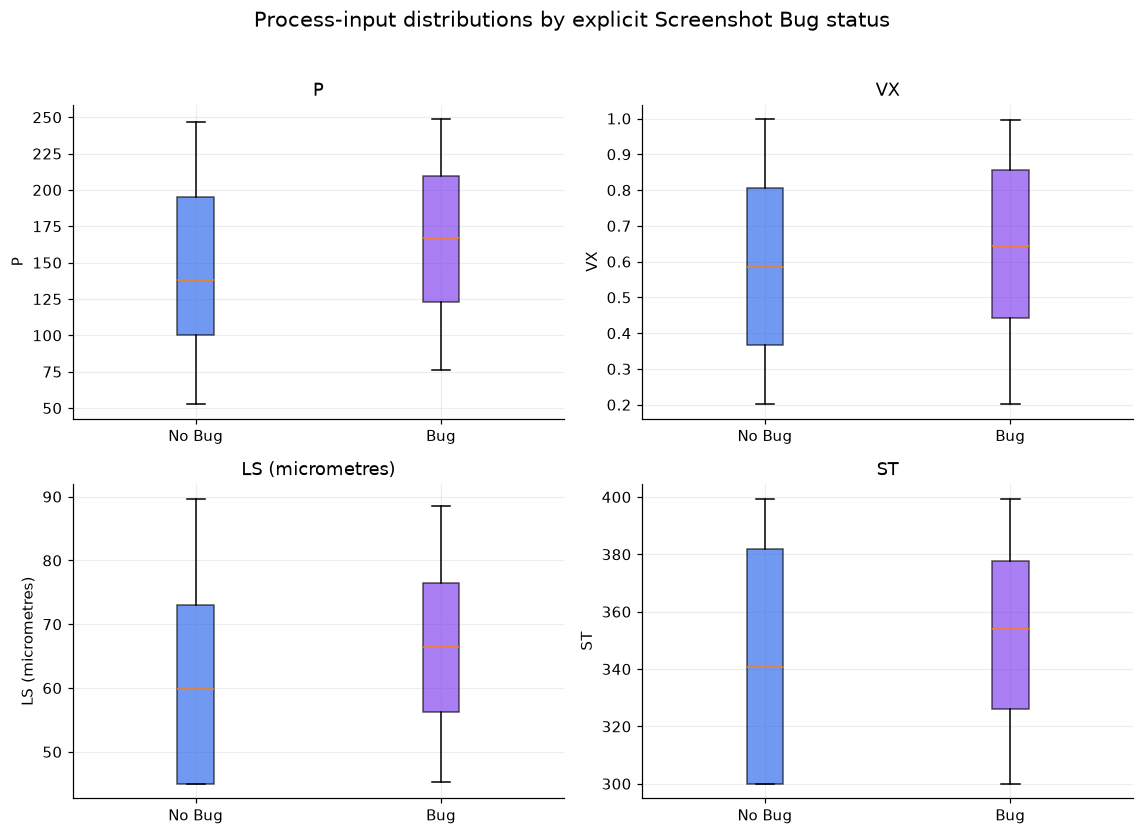

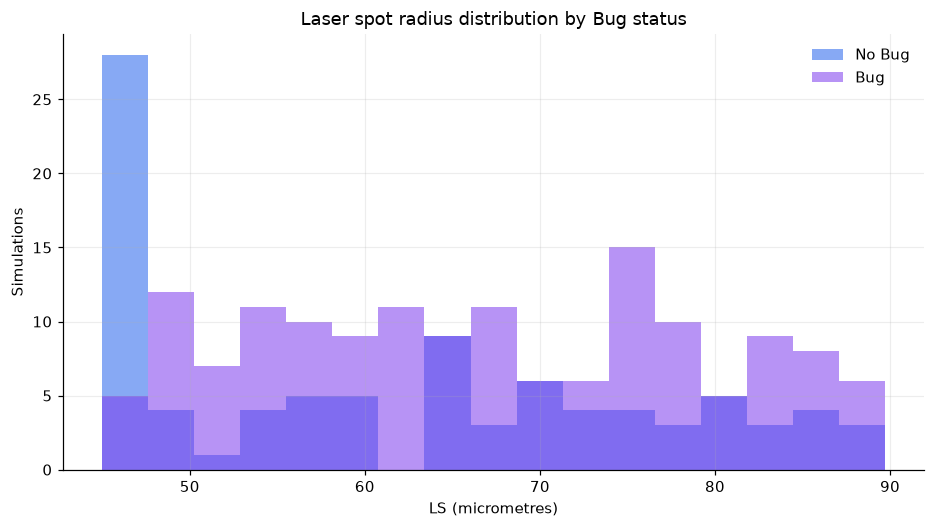

In [7]:
colors = {"Bug": "#7C3AED", "No Bug": "#2563EB"}
plot_vars = ["P", "VX", "LS_micrometres", "ST"]
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.7))
for axis, variable in zip(axes.flat, plot_vars):
    data = [sequence_features.loc[sequence_features["bug_group"].eq(group), variable].to_numpy() for group in ["No Bug", "Bug"]]
    box = axis.boxplot(data, tick_labels=["No Bug", "Bug"], patch_artist=True, showfliers=True)
    for patch, group in zip(box["boxes"], ["No Bug", "Bug"]):
        patch.set_facecolor(colors[group])
        patch.set_alpha(0.65)
    axis.set_title(variable_labels[variable])
    axis.set_ylabel(variable_labels[variable])
fig.suptitle("Process-input distributions by explicit Screenshot Bug status", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(OUTPUT_ROOT / "bug_vs_no_bug_input_distributions.png", bbox_inches="tight")
plt.show(); plt.close(fig)

fig, axis = plt.subplots(figsize=(8.6, 4.9))
bins = np.linspace(sequence_features["LS_micrometres"].min(), sequence_features["LS_micrometres"].max(), 18)
for group in ["No Bug", "Bug"]:
    axis.hist(sequence_features.loc[sequence_features["bug_group"].eq(group), "LS_micrometres"], bins=bins, alpha=0.55, label=group, color=colors[group])
axis.set_title("Laser spot radius distribution by Bug status")
axis.set_xlabel("LS (micrometres)")
axis.set_ylabel("Simulations")
axis.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ls_distribution_by_bug_status.png", bbox_inches="tight")
plt.show(); plt.close(fig)


**Interpretation.** These summaries compare the observed design distributions; they do not isolate a causal effect. A large LS difference may coexist with differences in P, VX, ST, target distribution or unrecorded batches.


## 6. Bug rate and sequence diagnostics by laser spot radius


In [8]:
sequence_features["LS_quantile_bin"] = pd.qcut(
    sequence_features["LS_micrometres"], q=5, duplicates="drop"
)

def ls_group_summary(group: pd.DataFrame, summary_type: str, label: str) -> dict:
    target = group["first_observed_conduction_timestep"].dropna()
    return {
        "summary_type": summary_type,
        "LS_group": label,
        "n": len(group),
        "LS_min_micrometres": group["LS_micrometres"].min(),
        "LS_median_micrometres": group["LS_micrometres"].median(),
        "LS_max_micrometres": group["LS_micrometres"].max(),
        "bug_probability": group["screenshot_bug_any"].mean(),
        "preconduction_bug_probability": group["screenshot_bug_before_first_observed_conduction"].mean(),
        "mean_initial_empty_like_timestep_width": group["initial_empty_like_block_timestep_width"].mean(),
        "median_initial_empty_like_timestep_width": group["initial_empty_like_block_timestep_width"].median(),
        "mean_screenshot_bug_frame_count": group["screenshot_bug_frame_count"].mean(),
        "median_first_observed_conduction_timestep": target.median(),
    }

quantile_rows = [
    ls_group_summary(group, "quantile_bin", str(label))
    for label, group in sequence_features.groupby("LS_quantile_bin", sort=True, observed=True)
]
exact_rows = [
    ls_group_summary(group, "exact_design_value_n_ge_5", f"{float(value):.6g} µm")
    for value, group in sequence_features.groupby("LS_micrometres", sort=True, observed=True)
    if len(group) >= 5
]
ls_bug_rate_summary = pd.DataFrame(quantile_rows + exact_rows)
ls_bug_rate_summary.to_csv(OUTPUT_ROOT / "ls_bug_rate_summary.csv", index=False)
display(ls_bug_rate_summary.round(5))


,summary_type,LS_group,n,LS_min_micrometres,LS_median_micrometres,LS_max_micrometres,bug_probability,preconduction_bug_probability,mean_initial_empty_like_timestep_width,median_initial_empty_like_timestep_width,mean_screenshot_bug_frame_count,median_first_observed_conduction_timestep
0,quantile_bin,"(44.999, 49.871]",49,45.00000,45.00000,49.87134,0.34694,0.32653,8761.36735,192.0,21.79592,21327.0
1,quantile_bin,"(49.871, 59.856]",48,50.44005,55.70535,59.85631,0.70833,0.70833,16558.31250,13044.5,38.60417,28234.0
2,quantile_bin,"(59.856, 68.82]",48,59.86865,64.60252,68.82035,0.72917,0.70833,18112.79167,15004.5,33.25000,31948.0
3,quantile_bin,"(68.82, 77.7]",48,68.88807,74.32754,77.69973,0.66667,0.66667,18543.60417,15889.0,27.31250,35947.0
4,quantile_bin,"(77.7, 89.704]",48,77.95295,84.11114,89.70399,0.66667,0.64583,15842.62500,13030.0,34.18750,34343.0
5,exact_design_value_n_ge_5,45 µm,27,45.00000,45.00000,45.00000,0.00000,0.00000,52.96296,0.0,0.00000,10329.0


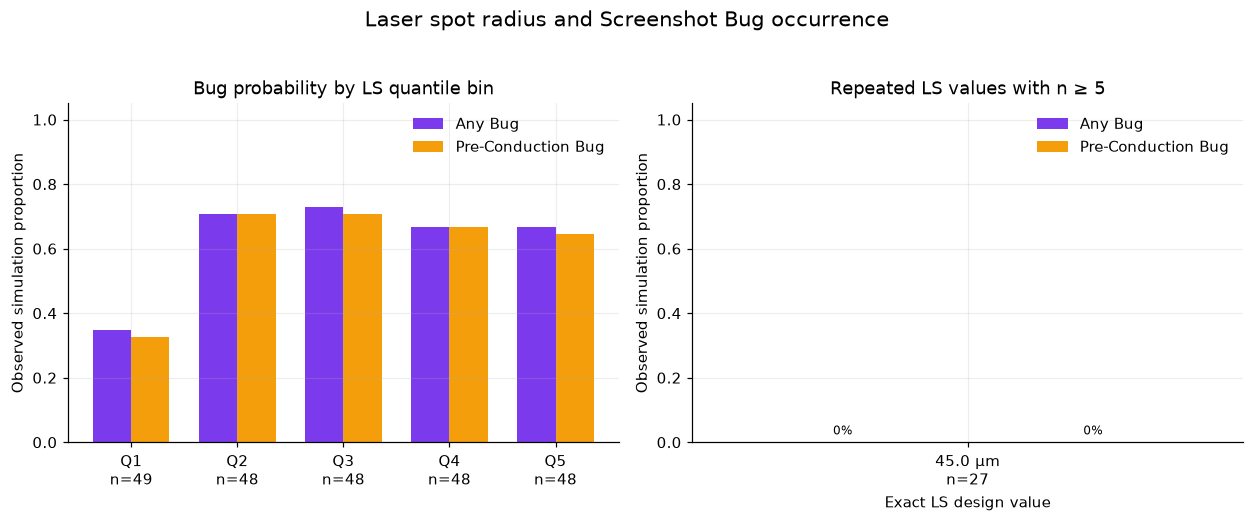

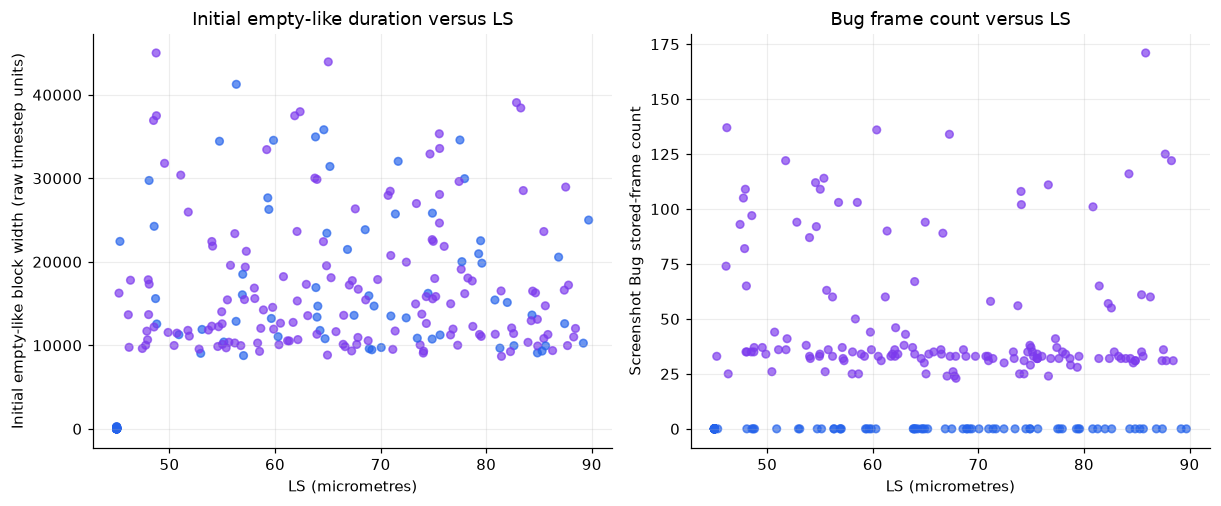

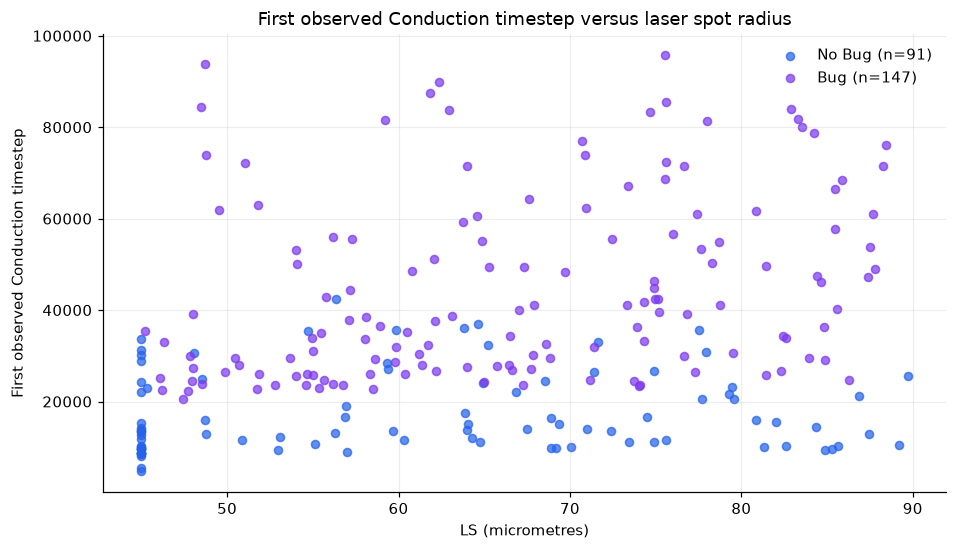

In [9]:
quantile_plot = ls_bug_rate_summary.loc[ls_bug_rate_summary["summary_type"].eq("quantile_bin")].copy()
exact_plot = ls_bug_rate_summary.loc[ls_bug_rate_summary["summary_type"].eq("exact_design_value_n_ge_5")].copy()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
x = np.arange(len(quantile_plot))
axes[0].bar(x - 0.18, quantile_plot["bug_probability"], width=0.36, label="Any Bug", color="#7C3AED")
axes[0].bar(x + 0.18, quantile_plot["preconduction_bug_probability"], width=0.36, label="Pre-Conduction Bug", color="#F59E0B")
axes[0].set_xticks(x, [f"Q{i+1}\nn={n}" for i, n in enumerate(quantile_plot["n"])])
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Observed simulation proportion")
axes[0].set_title("Bug probability by LS quantile bin")
axes[0].legend(frameon=False)

exact_plot = exact_plot.sort_values("LS_median_micrometres")
exact_x = np.arange(len(exact_plot))
axes[1].bar(exact_x - 0.18, exact_plot["bug_probability"], width=0.36, color="#7C3AED", label="Any Bug")
axes[1].bar(exact_x + 0.18, exact_plot["preconduction_bug_probability"], width=0.36, color="#F59E0B", label="Pre-Conduction Bug")
axes[1].set_xticks(exact_x, [f"{value:.1f} µm\nn={n}" for value, n in zip(exact_plot["LS_median_micrometres"], exact_plot["n"])])
axes[1].set_xlabel("Exact LS design value")
axes[1].set_ylabel("Observed simulation proportion")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Repeated LS values with n ≥ 5")
axes[1].legend(frameon=False)
for x_position, probability in zip(exact_x - 0.18, exact_plot["bug_probability"]):
    axes[1].text(x_position, max(float(probability), 0.015), f"{probability:.0%}", ha="center", va="bottom", fontsize=8)
for x_position, probability in zip(exact_x + 0.18, exact_plot["preconduction_bug_probability"]):
    axes[1].text(x_position, max(float(probability), 0.015), f"{probability:.0%}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Laser spot radius and Screenshot Bug occurrence", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(OUTPUT_ROOT / "ls_bug_rate_summary.png", bbox_inches="tight")
plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.7))
axes[0].scatter(sequence_features["LS_micrometres"], sequence_features["initial_empty_like_block_timestep_width"], c=sequence_features["screenshot_bug_any"].map({False: "#2563EB", True: "#7C3AED"}), alpha=0.68, s=25)
axes[0].set_xlabel("LS (micrometres)")
axes[0].set_ylabel("Initial empty-like block width (raw timestep units)")
axes[0].set_title("Initial empty-like duration versus LS")
axes[1].scatter(sequence_features["LS_micrometres"], sequence_features["screenshot_bug_frame_count"], c=sequence_features["screenshot_bug_any"].map({False: "#2563EB", True: "#7C3AED"}), alpha=0.68, s=25)
axes[1].set_xlabel("LS (micrometres)")
axes[1].set_ylabel("Screenshot Bug stored-frame count")
axes[1].set_title("Bug frame count versus LS")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ls_sequence_relationships.png", bbox_inches="tight")
plt.show(); plt.close(fig)

conduction_rows = sequence_features.loc[sequence_features["observed_conduction"]]
fig, axis = plt.subplots(figsize=(8.8, 5.1))
for group in ["No Bug", "Bug"]:
    subset = conduction_rows.loc[conduction_rows["bug_group"].eq(group)]
    axis.scatter(subset["LS_micrometres"], subset["first_observed_conduction_timestep"], label=f"{group} (n={len(subset)})", color=colors[group], alpha=0.72, s=28)
axis.set_xlabel("LS (micrometres)")
axis.set_ylabel("First observed Conduction timestep")
axis.set_title("First observed Conduction timestep versus laser spot radius")
axis.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "first_conduction_timestep_vs_ls.png", bbox_inches="tight")
plt.show(); plt.close(fig)


## 7. Descriptive associations for all four process inputs


In [10]:
association_targets = [
    "initial_empty_like_block_timestep_width",
    "screenshot_bug_frame_count",
    "first_observed_conduction_timestep",
]
association_rows = []
for group_label, group in [("All", sequence_features), ("Bug", bug_rows), ("No Bug", sequence_features.loc[~sequence_features["screenshot_bug_any"]])]:
    for predictor in ["P", "VX", "LS_micrometres", "ST"]:
        for outcome in association_targets:
            pair = group[[predictor, outcome]].dropna()
            if len(pair) < 3 or pair[predictor].nunique() < 2 or pair[outcome].nunique() < 2:
                rho, pvalue, status = np.nan, np.nan, "not_meaningful_constant_or_small_group"
            else:
                result = spearmanr(pair[predictor], pair[outcome])
                rho, pvalue, status = float(result.statistic), float(result.pvalue), "calculated"
            association_rows.append({
                "group": group_label,
                "predictor": predictor,
                "outcome": outcome,
                "n": len(pair),
                "spearman_rho": rho,
                "two_sided_p_value": pvalue,
                "status": status,
            })
input_bug_association_summary = pd.DataFrame(association_rows)
input_bug_association_summary.to_csv(OUTPUT_ROOT / "input_bug_association_summary.csv", index=False)
display(input_bug_association_summary.loc[input_bug_association_summary["group"].eq("All")].round(5))


,group,predictor,outcome,n,spearman_rho,two_sided_p_value,status
0,All,P,initial_empty_like_block_timestep_width,241,0.07377,0.25395,calculated
1,All,P,screenshot_bug_frame_count,241,0.01216,0.85098,calculated
2,All,P,first_observed_conduction_timestep,238,0.08124,0.21174,calculated
3,All,VX,initial_empty_like_block_timestep_width,241,-0.72963,0.00000,calculated
4,All,VX,screenshot_bug_frame_count,241,0.28901,0.00001,calculated
5,All,VX,first_observed_conduction_timestep,238,-0.51295,0.00000,calculated
6,All,LS_micrometres,initial_empty_like_block_timestep_width,241,0.28402,0.00001,calculated
7,All,LS_micrometres,screenshot_bug_frame_count,241,0.08873,0.16977,calculated
8,All,LS_micrometres,first_observed_conduction_timestep,238,0.31891,0.00000,calculated
9,All,ST,initial_empty_like_block_timestep_width,241,0.34676,0.00000,calculated


**Interpretation.** Spearman's rho measures monotonic association, not causal influence. P, VX and ST are reported beside LS so that an LS pattern is not interpreted in isolation. Undefined correlations are retained explicitly when an outcome is constant, such as Bug count in the no-Bug group.


## 8. Small multivariable Bug-presence diagnostic


In [11]:
logistic_specs = {
    "LS_only": ["LS"],
    "four_inputs": ["P", "VX", "LS", "ST"],
}
y_bug = sequence_features["screenshot_bug_any"].astype(int).to_numpy()
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
logistic_rows = []
logistic_oof = []

for model_name, predictors in logistic_specs.items():
    X = sequence_features[predictors].to_numpy(float)
    fold_aucs = []
    oof_probability = np.full(len(sequence_features), np.nan)
    for fold_index, (train_index, test_index) in enumerate(splitter.split(X, y_bug)):
        scaler = StandardScaler().fit(X[train_index])
        X_train = scaler.transform(X[train_index])
        X_test = scaler.transform(X[test_index])
        model = LogisticRegression(solver="lbfgs", max_iter=2000, random_state=RANDOM_SEED)
        model.fit(X_train, y_bug[train_index])
        probability = model.predict_proba(X_test)[:, 1]
        oof_probability[test_index] = probability
        fold_auc = roc_auc_score(y_bug[test_index], probability)
        fold_aucs.append(float(fold_auc))
        logistic_oof.extend({
            "model": model_name,
            "fold_index": fold_index,
            "name": sequence_features.iloc[index]["name"],
            "observed_bug": int(y_bug[index]),
            "predicted_bug_probability": float(oof_probability[index]),
        } for index in test_index)

    full_scaler = StandardScaler().fit(X)
    full_model = LogisticRegression(solver="lbfgs", max_iter=2000, random_state=RANDOM_SEED).fit(full_scaler.transform(X), y_bug)
    overall_oof_auc = float(roc_auc_score(y_bug, oof_probability))
    for predictor, coefficient in zip(predictors, full_model.coef_[0]):
        logistic_rows.append({
            "model": model_name,
            "predictor": predictor,
            "standardized_coefficient": float(coefficient),
            "full_data_intercept": float(full_model.intercept_[0]),
            "cv_folds": 5,
            "mean_fold_ROC_AUC": float(np.mean(fold_aucs)),
            "std_fold_ROC_AUC": float(np.std(fold_aucs, ddof=1)),
            "overall_out_of_fold_ROC_AUC": overall_oof_auc,
            "fold_ROC_AUC_values": json.dumps(fold_aucs),
            "n": len(sequence_features),
            "positive_bug_simulations": int(y_bug.sum()),
            "interpretation": "association/predictive diagnostic; not causal",
        })

bug_logistic_regression_summary = pd.DataFrame(logistic_rows)
bug_logistic_regression_summary.to_csv(OUTPUT_ROOT / "bug_logistic_regression_summary.csv", index=False)
logistic_oof = pd.DataFrame(logistic_oof)
display(bug_logistic_regression_summary.round(5))


,model,predictor,standardized_coefficient,full_data_intercept,cv_folds,mean_fold_ROC_AUC,std_fold_ROC_AUC,overall_out_of_fold_ROC_AUC,fold_ROC_AUC_values,n,positive_bug_simulations,interpretation
0,LS_only,LS,0.40301,0.51982,5,0.62037,0.12799,0.59516,"[0.5666666666666667, 0.7981481481481482, 0.4740740740740741, 0.7, 0.5629629629629629]",241,150,association/predictive diagnostic; not causal
1,four_inputs,P,0.25619,0.52880,5,0.61064,0.14762,0.59260,"[0.5421052631578946, 0.8388888888888889, 0.43703703703703706, 0.625925925925926, 0.6092592592592593]",241,150,association/predictive diagnostic; not causal
2,four_inputs,VX,0.16181,0.52880,5,0.61064,0.14762,0.59260,"[0.5421052631578946, 0.8388888888888889, 0.43703703703703706, 0.625925925925926, 0.6092592592592593]",241,150,association/predictive diagnostic; not causal
3,four_inputs,LS,0.30115,0.52880,5,0.61064,0.14762,0.59260,"[0.5421052631578946, 0.8388888888888889, 0.43703703703703706, 0.625925925925926, 0.6092592592592593]",241,150,association/predictive diagnostic; not causal
4,four_inputs,ST,0.18395,0.52880,5,0.61064,0.14762,0.59260,"[0.5421052631578946, 0.8388888888888889, 0.43703703703703706, 0.625925925925926, 0.6092592592592593]",241,150,association/predictive diagnostic; not causal


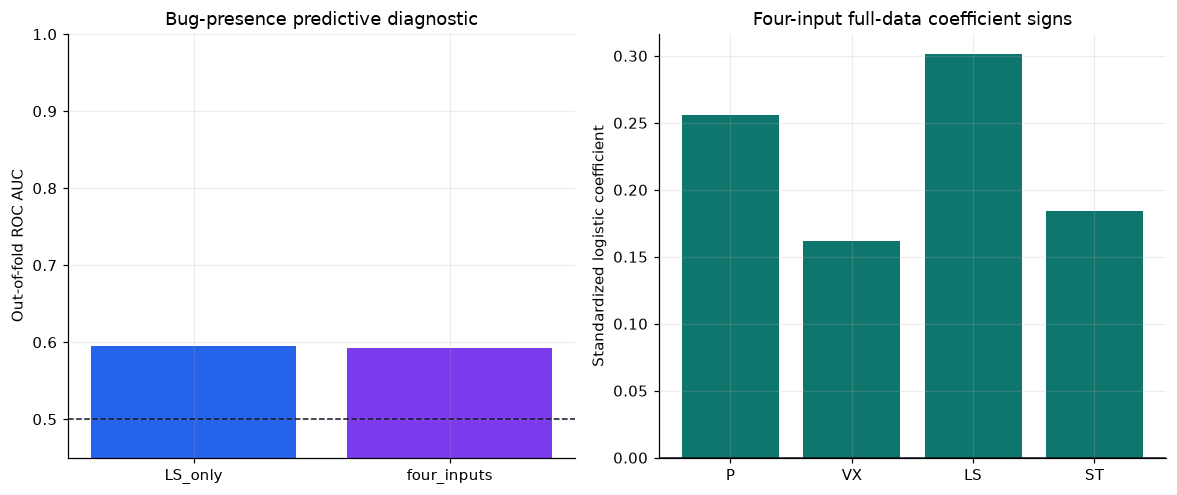


**Plain-language interpretation.** LS-only out-of-fold ROC AUC is **0.595** and the four-input model is **0.593**, a difference of **-0.003**. The standardized LS coefficient is **+0.403** alone and **+0.301** after including P, VX and ST. These values describe association and prediction within this designed dataset; they do not demonstrate that changing LS causes a Bug label.


In [12]:
model_auc = bug_logistic_regression_summary.groupby("model", observed=True)["overall_out_of_fold_ROC_AUC"].first()
auc_difference = float(model_auc["four_inputs"] - model_auc["LS_only"])

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.6))
axes[0].bar(model_auc.index, model_auc.values, color=["#2563EB", "#7C3AED"])
axes[0].axhline(0.5, linestyle="--", color="#111827", linewidth=1)
axes[0].set_ylim(0.45, 1.0)
axes[0].set_ylabel("Out-of-fold ROC AUC")
axes[0].set_title("Bug-presence predictive diagnostic")
coefficient_plot = bug_logistic_regression_summary.loc[bug_logistic_regression_summary["model"].eq("four_inputs")]
axes[1].bar(coefficient_plot["predictor"], coefficient_plot["standardized_coefficient"], color="#0F766E")
axes[1].axhline(0, color="#111827", linewidth=1)
axes[1].set_ylabel("Standardized logistic coefficient")
axes[1].set_title("Four-input full-data coefficient signs")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "bug_logistic_regression_diagnostic.png", bbox_inches="tight")
plt.show(); plt.close(fig)

ls_coef_only = float(bug_logistic_regression_summary.query("model == 'LS_only' and predictor == 'LS'")["standardized_coefficient"].iloc[0])
ls_coef_four = float(bug_logistic_regression_summary.query("model == 'four_inputs' and predictor == 'LS'")["standardized_coefficient"].iloc[0])
display(Markdown(f'''
**Plain-language interpretation.** LS-only out-of-fold ROC AUC is **{model_auc['LS_only']:.3f}** and the four-input model is **{model_auc['four_inputs']:.3f}**, a difference of **{auc_difference:+.3f}**. The standardized LS coefficient is **{ls_coef_only:+.3f}** alone and **{ls_coef_four:+.3f}** after including P, VX and ST. These values describe association and prediction within this designed dataset; they do not demonstrate that changing LS causes a Bug label.
'''))


## 9. Largest existing Matérn 3/2 LOO errors


In [13]:
def add_input_space_diagnostics(predictions: pd.DataFrame, dataset_features: pd.DataFrame) -> pd.DataFrame:
    feature_index = dataset_features.set_index("name")
    rows = []
    target_percentile = predictions.set_index("name")["observed_target"].rank(method="average", pct=True)
    for row in predictions.itertuples(index=False):
        train = dataset_features.loc[dataset_features["name"].ne(row.name)].copy()
        scaler = StandardScaler().fit(train[INPUTS])
        train_scaled = scaler.transform(train[INPUTS])
        heldout_scaled = scaler.transform(feature_index.loc[[row.name], INPUTS])[0]
        distances = np.linalg.norm(train_scaled - heldout_scaled, axis=1)
        order = np.argsort(distances)
        nearest_name = train.iloc[order[0]]["name"]
        mean_5nn = float(np.mean(distances[order[: min(5, len(order))]]))
        heldout_raw = feature_index.loc[row.name, INPUTS].astype(float)
        train_min = train[INPUTS].min()
        train_max = train[INPUTS].max()
        boundary_dimensions = [column for column in INPUTS if heldout_raw[column] <= train_min[column] or heldout_raw[column] >= train_max[column]]
        rows.append({
            "name": row.name,
            "nearest_neighbor_name": nearest_name,
            "nearest_neighbor_distance_standardized": float(distances[order[0]]),
            "mean_5nn_distance_standardized": mean_5nn,
            "inverse_mean_5nn_density_proxy": float(1.0 / (mean_5nn + 1e-12)),
            "process_boundary_dimension_count": len(boundary_dimensions),
            "process_boundary_dimensions": ";".join(boundary_dimensions),
            "first_observed_conduction_percentile": float(target_percentile.loc[row.name]),
            "first_observed_conduction_quantile": f"Q{min(4, max(1, math.ceil(float(target_percentile.loc[row.name]) * 4)))}",
        })
    return predictions.merge(pd.DataFrame(rows), on="name", how="left", validate="one_to_one")

def prepare_high_error_table(dataset: str, prediction_path: Path, top_n: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    predictions = pd.read_csv(prediction_path)
    predictions = predictions.loc[predictions["kernel_key"].eq("matern_3_2")].copy()
    dataset_features = sequence_features.loc[sequence_features["observed_conduction"]].copy()
    if dataset == "clean":
        dataset_features = dataset_features.loc[~dataset_features["screenshot_bug_any"]].copy()
    enriched = add_input_space_diagnostics(predictions, dataset_features)
    merge_columns = [
        "name", "LS_micrometres", "initial_emptiness_frame_count", "screenshot_bug_frame_count",
        "initial_empty_like_block_timestep_width", "sequence_pattern_category", "label_sequence_rle",
    ]
    enriched = enriched.merge(sequence_features[merge_columns], on="name", how="left", validate="one_to_one")
    enriched["sparse_region_threshold_90pct"] = enriched["mean_5nn_distance_standardized"].quantile(0.90)
    enriched["sparse_region_top_decile"] = enriched["mean_5nn_distance_standardized"] >= enriched["sparse_region_threshold_90pct"]
    top = enriched.nlargest(top_n, "absolute_error").copy()
    selected = [
        "name", "P", "VX", "LS", "LS_micrometres", "ST", "observed_target", "predicted_mean",
        "predicted_std", "absolute_error", "residual_observed_minus_predicted", "covered_95",
        "screenshot_bug_any", "initial_emptiness_frame_count", "screenshot_bug_frame_count",
        "initial_empty_like_block_timestep_width", "sequence_pattern_category",
        "first_observed_conduction_percentile", "first_observed_conduction_quantile",
        "nearest_neighbor_name", "nearest_neighbor_distance_standardized", "mean_5nn_distance_standardized",
        "inverse_mean_5nn_density_proxy", "sparse_region_top_decile", "process_boundary_dimension_count",
        "process_boundary_dimensions", "label_sequence_rle",
    ]
    return top[selected], enriched

clean_high_error, clean_matern_all = prepare_high_error_table("clean", CLEAN_PRED_PATH, 10)
broad_high_error, broad_matern_all = prepare_high_error_table("broad", BROAD_PRED_PATH, 20)
clean_high_error.to_csv(OUTPUT_ROOT / "clean_matern32_high_error_cases.csv", index=False)
broad_high_error.to_csv(OUTPUT_ROOT / "broad_matern32_high_error_cases.csv", index=False)
display(clean_high_error)
display(broad_high_error.head(20))


,name,P,VX,LS,LS_micrometres,ST,observed_target,predicted_mean,predicted_std,absolute_error,residual_observed_minus_predicted,covered_95,screenshot_bug_any,initial_emptiness_frame_count,screenshot_bug_frame_count,initial_empty_like_block_timestep_width,sequence_pattern_category,first_observed_conduction_percentile,first_observed_conduction_quantile,nearest_neighbor_name,nearest_neighbor_distance_standardized,mean_5nn_distance_standardized,inverse_mean_5nn_density_proxy,sparse_region_top_decile,process_boundary_dimension_count,process_boundary_dimensions,label_sequence_rle
32,P-110p131967455_VX-0p225166085115_LS-5p63312318207e-05_ST-326p092691949_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,110.13197,0.22517,0.00006,56.33123,326.09269,42436.0,31446.78405,5142.59275,10989.21595,10989.21595,False,False,36,0,41256.0,no_bug,1.00000,Q4,P-109p759946449_VX-0p241926176876_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-7p...,1.05407,1.11289,0.89856,False,0,,Initial Emptiness × 36 → Conduction × 64
65,P-210p464738138_VX-0p237113609615_LS-6p46217439158e-05_ST-306p057190902_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,210.46474,0.23711,0.00006,64.62174,306.05719,36935.0,28976.43159,5209.76309,7958.56841,7958.56841,True,False,33,0,35815.0,no_bug,0.98901,Q4,P-199p092557979_VX-0p316505824784_LS-5p93128195415e-05_ST-330p512210532_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,0.84877,1.13781,0.87888,False,0,,Initial Emptiness × 33 → Conduction × 72
71,P-225p511353261_VX-0p242923031869_LS-6p38341457094e-05_ST-340p774386379_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,225.51135,0.24292,0.00006,63.83415,340.77439,36051.0,30051.43641,4443.27303,5999.56359,5999.56359,True,False,33,0,34957.0,no_bug,0.97802,Q4,P-199p092557979_VX-0p316505824784_LS-5p93128195415e-05_ST-330p512210532_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,0.69930,0.96598,1.03521,False,0,,Initial Emptiness × 33 → Conduction × 74
56,P-188p623199531_VX-0p253450423389_LS-5p98563054886e-05_ST-373p9812389_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012...,188.62320,0.25345,0.00006,59.85631,373.98124,35600.0,29777.13364,4649.61766,5822.86636,5822.86636,True,False,34,0,34552.0,no_bug,0.95604,Q4,P-191p425479448_VX-0p407642571095_LS-6p68635438353e-05_ST-376p486404344_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,0.79476,0.97535,1.02527,False,0,,Initial Emptiness × 34 → Conduction × 78
45,P-145p199982561_VX-0p253198682602_LS-7p7513591008e-05_ST-398p693210886_M-TI64_XI-0p0002_XF-0p0014_XL-0p001...,145.19998,0.25320,0.00008,77.51359,398.69321,35635.0,30821.33619,3525.66565,4813.66381,4813.66381,True,False,34,0,34586.0,no_bug,0.96703,Q4,P-149p381043177_VX-0p292260061908_LS-7p79529508561e-05_ST-384p444199936_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,0.42860,1.08566,0.92110,False,0,,Initial Emptiness × 34 → Conduction × 78
15,P-53p4525830151_VX-0p394191978834_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-4p...,53.45258,0.39419,0.00005,45.00000,300.00000,9915.0,14527.77849,2827.95358,4612.77849,-4612.77849,True,False,2,0,261.0,no_bug,0.19780,Q1,P-55p2363598851_VX-0p252312006514_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-7p...,0.57315,0.71623,1.39620,False,2,LS;ST,Initial Emptiness × 2 → Forming Phase × 36 → Conduction × 227
61,P-199p092557979_VX-0p316505824784_LS-5p93128195415e-05_ST-330p512210532_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,199.09256,0.31651,0.00006,59.31282,330.51221,28501.0,33096.73450,3432.58043,4595.73450,-4595.73450,True,False,34,0,27661.0,no_bug,0.84615,Q4,P-225p511353261_VX-0p242923031869_LS-6p38341457094e-05_ST-340p774386379_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,0.69680,0.80440,1.24316,False,0,,Initial Emptiness × 34 → Conduction × 105
5,P-133p757797566_VX-0p645163458122_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-2p...,133.75780,0.64516,0.00005,45.00000,300.00000,12754.0,17328.39755,2279.37799,4574.39755,-4574.39755,False,False,1,0,0.0,no_bug,0.39560,Q2,P-133p003569327_VX-0p736244453131_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0

,name,P,VX,LS,LS_micrometres,ST,observed_target,predicted_mean,predicted_std,absolute_error,residual_observed_minus_predicted,covered_95,screenshot_bug_any,initial_emptiness_frame_count,screenshot_bug_frame_count,initial_empty_like_block_timestep_width,sequence_pattern_category,first_observed_conduction_percentile,first_observed_conduction_quantile,nearest_neighbor_name,nearest_neighbor_distance_standardized,mean_5nn_distance_standardized,inverse_mean_5nn_density_proxy,sparse_region_top_decile,process_boundary_dimension_count,process_boundary_dimensions,label_sequence_rle
236,P-97p5646849269_VX-0p800614374072_LS-8p74302358335e-05_ST-345p052442693_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,97.56468,0.80061,0.00009,87.43024,345.05244,12927.0,73686.62956,16068.43036,60759.62956,-60759.62956,False,False,83,0,12596.0,no_bug,0.15546,Q1,P-78p3109819881_VX-0p819836919071_LS-8p42620704062e-05_ST-359p367913591_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,0.62317,0.78881,1.26773,False,0,,Initial Emptiness × 38 → Conduction × 265 → Initial Emptiness × 45
156,P-82p6239965333_VX-0p567384090403_LS-6p29636633496e-05_ST-368p216750002_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,82.62400,0.56738,0.00006,62.96366,368.21675,83769.0,25950.86164,15298.22206,57818.13836,57818.13836,False,True,0,38,17303.0,initial_empty_like_block_bug_only,0.97059,Q4,P-100p408926704_VX-0p564694322144_LS-6p38706769001e-05_ST-381p633419878_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,0.53659,0.81777,1.22284,False,0,,Screenshot Bug × 38 → Forming Phase × 141 → Conduction × 69
162,P-90p3577538021_VX-0p606625134218_LS-7p79676391387e-05_ST-345p062824899_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,90.35775,0.60663,0.00008,77.96764,345.06282,81413.0,26365.00097,15072.77916,55047.99903,55047.99903,False,True,0,35,16185.0,initial_empty_like_block_bug_only,0.95378,Q4,P-91p4898167395_VX-0p477122889388_LS-7p769973149e-05_ST-351p010780102_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012...,0.57011,0.73359,1.36316,False,0,,Screenshot Bug × 35 → Forming Phase × 148 → Conduction × 80
130,P-238p319282705_VX-0p253960262605_LS-5p92121677448e-05_ST-384p128817665_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,238.31928,0.25396,0.00006,59.21217,384.12882,81551.0,30050.87792,19450.89963,51500.12208,51500.12208,False,True,0,33,33436.0,initial_empty_like_block_bug_only,0.95798,Q4,P-188p623199531_VX-0p253450423389_LS-5p98563054886e-05_ST-373p9812389_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012...,0.99287,1.10286,0.90673,True,0,,Screenshot Bug × 33 → Forming Phase × 45 → Conduction × 34
203,P-188p623199531_VX-0p253450423389_LS-5p98563054886e-05_ST-373p9812389_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012...,188.62320,0.25345,0.00006,59.85631,373.98124,35600.0,77851.36847,14348.92077,42251.36847,-42251.36847,False,False,34,0,34552.0,no_bug,0.64706,Q3,P-173p720948038_VX-0p230617607979_LS-6p23730108092e-05_ST-383p499521736_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,0.45704,0.71099,1.40649,False,0,,Initial Emptiness × 34 → Conduction × 78
68,P-171p382540224_VX-0p233605939402_LS-6p18629013601e-05_ST-355p188153249_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,171.38254,0.23361,0.00006,61.86290,355.18815,87522.0,46217.35148,17399.13968,41304.64852,41304.64852,False,True,0,34,37490.0,initial_empty_like_block_bug_only,0.98739,Q4,P-188p623199531_VX-0p253450423389_LS-5p98563054886e-05_ST-373p9812389_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012...,0.68393,0.81835,1.22197,False,0,,Screenshot Bug × 34 → Forming Phase × 43 → Conduction × 26
175,P-100p408926704_VX-0p564694322144_LS-6p38706769001e-05_ST-381p633419878_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,100.40893,0.56469,0.00006,63.87068,381.63342,17386.0,53971.59082,15274.28147,36585.59082,-36585.59082,False,False,37,0,16916.0,no_bug,0.24790,Q1,P-82p6239965333_VX-0p567384090403_LS-6p29636633496e-05_ST-368p216750002_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,0.53666,0.80626,1.24030,False,0,,Initial Emptiness × 37 → Conduction × 210
213,P-213p87237204_VX-0p329966780459_LS-7p13970627017e-05_ST-390p008507958_M-TI64_XI-0p0002_XF-0p0014_XL-0p001...,213.87237,

In [14]:
diagnostic_rows = []
for dataset, top, all_rows in [
    ("clean", clean_high_error, clean_matern_all),
    ("broad", broad_high_error, broad_matern_all),
]:
    diagnostic_rows.append({
        "dataset": dataset,
        "top_case_count": len(top),
        "top_case_bug_rate": top["screenshot_bug_any"].mean(),
        "all_case_bug_rate": all_rows["screenshot_bug_any"].mean(),
        "top_median_LS_micrometres": top["LS_micrometres"].median(),
        "all_median_LS_micrometres": all_rows["LS_micrometres"].median(),
        "top_median_absolute_error": top["absolute_error"].median(),
        "top_early_or_late_target_count_Q1_or_Q4": int(top["first_observed_conduction_quantile"].isin(["Q1", "Q4"]).sum()),
        "top_sparse_region_count": int(top["sparse_region_top_decile"].sum()),
        "top_process_boundary_count": int(top["process_boundary_dimension_count"].gt(0).sum()),
        "top_median_5nn_distance": top["mean_5nn_distance_standardized"].median(),
        "all_median_5nn_distance": all_rows["mean_5nn_distance_standardized"].median(),
        "top_dominant_sequence_pattern": top["sequence_pattern_category"].mode().iloc[0],
        "top_outside_95_interval_count": int((~top["covered_95"]).sum()),
    })
matern32_error_diagnostic_summary = pd.DataFrame(diagnostic_rows)
matern32_error_diagnostic_summary.to_csv(OUTPUT_ROOT / "matern32_error_diagnostic_summary.csv", index=False)
display(matern32_error_diagnostic_summary)


,dataset,top_case_count,top_case_bug_rate,all_case_bug_rate,top_median_LS_micrometres,all_median_LS_micrometres,top_median_absolute_error,top_early_or_late_target_count_Q1_or_Q4,top_sparse_region_count,top_process_boundary_count,top_median_5nn_distance,all_median_5nn_distance,top_dominant_sequence_pattern,top_outside_95_interval_count
0,clean,10,0.00,0.00000,59.58456,59.85631,4713.22115,8,1,4,0.97067,0.96598,no_bug,3
1,broad,20,0.55,0.61765,75.76541,64.42150,35091.90270,15,4,0,0.80096,0.76027,initial_empty_like_block_bug_only,15


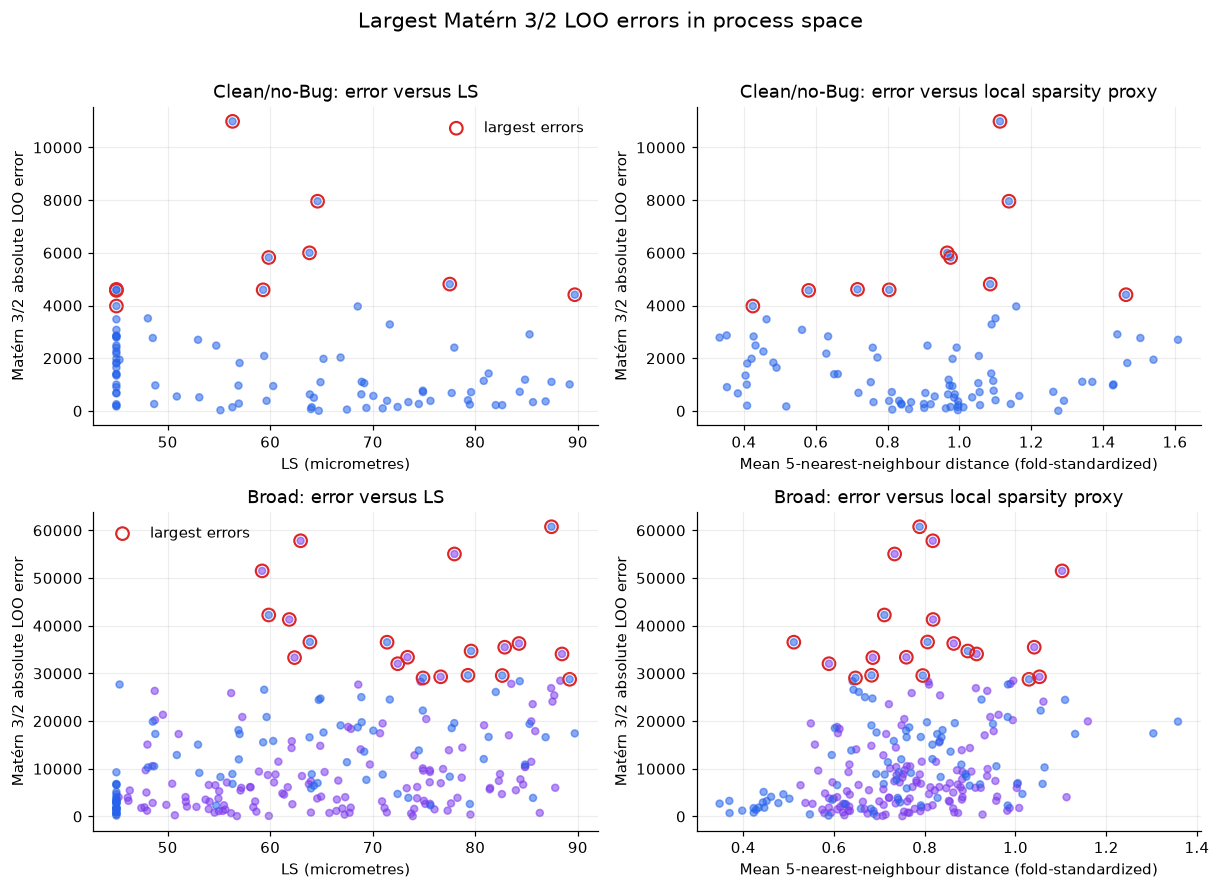

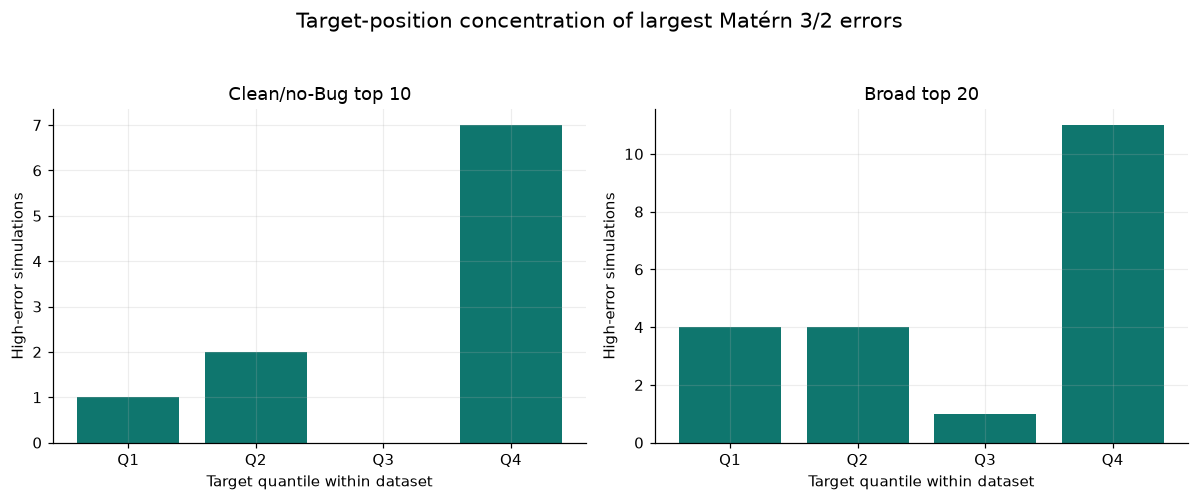

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11.2, 8.2))
for row_index, (dataset, all_rows, top) in enumerate([
    ("Clean/no-Bug", clean_matern_all, clean_high_error),
    ("Broad", broad_matern_all, broad_high_error),
]):
    color_values = all_rows["screenshot_bug_any"].map({False: "#2563EB", True: "#7C3AED"})
    axes[row_index, 0].scatter(all_rows["LS_micrometres"], all_rows["absolute_error"], c=color_values, alpha=0.55, s=21)
    axes[row_index, 0].scatter(top["LS_micrometres"], top["absolute_error"], facecolors="none", edgecolors="#DC2626", s=68, linewidth=1.4, label="largest errors")
    axes[row_index, 0].set_xlabel("LS (micrometres)")
    axes[row_index, 0].set_ylabel("Matérn 3/2 absolute LOO error")
    axes[row_index, 0].set_title(f"{dataset}: error versus LS")
    axes[row_index, 0].legend(frameon=False)

    axes[row_index, 1].scatter(all_rows["mean_5nn_distance_standardized"], all_rows["absolute_error"], c=color_values, alpha=0.55, s=21)
    axes[row_index, 1].scatter(top["mean_5nn_distance_standardized"], top["absolute_error"], facecolors="none", edgecolors="#DC2626", s=68, linewidth=1.4)
    axes[row_index, 1].set_xlabel("Mean 5-nearest-neighbour distance (fold-standardized)")
    axes[row_index, 1].set_ylabel("Matérn 3/2 absolute LOO error")
    axes[row_index, 1].set_title(f"{dataset}: error versus local sparsity proxy")
fig.suptitle("Largest Matérn 3/2 LOO errors in process space", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(OUTPUT_ROOT / "matern32_high_error_input_space_diagnostics.png", bbox_inches="tight")
plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))
for axis, (dataset, top) in zip(axes, [("Clean/no-Bug top 10", clean_high_error), ("Broad top 20", broad_high_error)]):
    counts = top["first_observed_conduction_quantile"].value_counts().reindex(["Q1", "Q2", "Q3", "Q4"], fill_value=0)
    axis.bar(counts.index, counts.values, color="#0F766E")
    axis.set_title(dataset)
    axis.set_xlabel("Target quantile within dataset")
    axis.set_ylabel("High-error simulations")
fig.suptitle("Target-position concentration of largest Matérn 3/2 errors", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(OUTPUT_ROOT / "matern32_high_error_target_quantiles.png", bbox_inches="tight")
plt.show(); plt.close(fig)


In [16]:
clean_diag = matern32_error_diagnostic_summary.set_index("dataset").loc["clean"]
broad_diag = matern32_error_diagnostic_summary.set_index("dataset").loc["broad"]
display(Markdown(f'''
**High-error interpretation.** In the clean/no-Bug top 10, **{int(clean_diag.top_early_or_late_target_count_Q1_or_Q4)}** cases are in the earliest/latest target quartiles, **{int(clean_diag.top_sparse_region_count)}** are in the top decile of the local-sparsity proxy, and **{int(clean_diag.top_process_boundary_count)}** lie on at least one leave-one-out training-range boundary. In the broad top 20, the corresponding counts are **{int(broad_diag.top_early_or_late_target_count_Q1_or_Q4)}**, **{int(broad_diag.top_sparse_region_count)}**, and **{int(broad_diag.top_process_boundary_count)}**; the Bug share is **{broad_diag.top_case_bug_rate:.1%}** versus **{broad_diag.all_case_bug_rate:.1%}** across all broad Matérn 3/2 predictions.

These diagnostics identify clustering patterns but do not justify deleting outliers or changing the fixed target.
'''))



**High-error interpretation.** In the clean/no-Bug top 10, **8** cases are in the earliest/latest target quartiles, **1** are in the top decile of the local-sparsity proxy, and **4** lie on at least one leave-one-out training-range boundary. In the broad top 20, the corresponding counts are **15**, **4**, and **0**; the Bug share is **55.0%** versus **61.8%** across all broad Matérn 3/2 predictions.

These diagnostics identify clustering patterns but do not justify deleting outliers or changing the fixed target.


## 10. Reinterpret the clean/no-Bug versus broad result


In [17]:
ls_group = bug_vs_no_bug_input_summary.loc[bug_vs_no_bug_input_summary["variable"].eq("LS_micrometres")].set_index("bug_group")
target_group = bug_vs_no_bug_input_summary.loc[bug_vs_no_bug_input_summary["variable"].eq("first_observed_conduction_timestep")].set_index("bug_group")
initial_width_group = sequence_features.groupby("bug_group", observed=True)["initial_empty_like_block_timestep_width"].median()
display(Markdown(f'''
The Phase 2 same-clean-points experiment showed that adding the broad subgroup worsened prediction on the same 91 no-Bug held-out targets for all four kernels. Under the supervisor's clarification, this should **not** be read as proof that Bug-labelled simulations are invalid. The explicit labels show different subgroup composition: median LS is **{ls_group.loc['Bug','median']:.2f} µm** for Bug and **{ls_group.loc['No Bug','median']:.2f} µm** for no-Bug simulations; median first observed Conduction timestep is **{target_group.loc['Bug','median']:.0f}** versus **{target_group.loc['No Bug','median']:.0f}**; and median initial empty-like raw-timestep width is **{initial_width_group['Bug']:.0f}** versus **{initial_width_group['No Bug']:.0f}**.

The performance gap is therefore consistent with subgroup/design heterogeneity, different process-space coverage and target distributions, different empty-like sequence duration, or unrecorded batch factors not represented in `[P, VX, LS, ST]`. The no-Bug subset remains useful as an operational sensitivity subgroup; it is not confirmed to be higher quality. Broad inclusion remains the fixed data policy.
'''))



The Phase 2 same-clean-points experiment showed that adding the broad subgroup worsened prediction on the same 91 no-Bug held-out targets for all four kernels. Under the supervisor's clarification, this should **not** be read as proof that Bug-labelled simulations are invalid. The explicit labels show different subgroup composition: median LS is **66.48 µm** for Bug and **59.86 µm** for no-Bug simulations; median first observed Conduction timestep is **38782** versus **13933**; and median initial empty-like raw-timestep width is **14394** versus **11784**.

The performance gap is therefore consistent with subgroup/design heterogeneity, different process-space coverage and target distributions, different empty-like sequence duration, or unrecorded batch factors not represented in `[P, VX, LS, ST]`. The no-Bug subset remains useful as an operational sensitivity subgroup; it is not confirmed to be higher quality. Broad inclusion remains the fixed data policy.


## 11. Save structured summary and validate


In [18]:
sequence_metrics = {row["metric"]: {"count": row["count"], "denominator": row["denominator"], "percentage": row["percentage"]} for row in sequence_summary_rows}
logistic_model_summary = {
    model: {
        "overall_out_of_fold_ROC_AUC": float(group["overall_out_of_fold_ROC_AUC"].iloc[0]),
        "mean_fold_ROC_AUC": float(group["mean_fold_ROC_AUC"].iloc[0]),
        "standardized_coefficients": dict(zip(group["predictor"], group["standardized_coefficient"])),
    }
    for model, group in bug_logistic_regression_summary.groupby("model", observed=True)
}

summary = {
    "experiment": "Week 5 Experiment 03 — Bug, Initial Emptiness and laser-radius diagnostics",
    "execution_date": date.today().isoformat(),
    "provenance": {"hugging_face_repository": HF_REPOSITORY, "filename": HF_FILENAME, "revision": HF_REVISION, "sha256": raw_sha256},
    "fixed_target": "minimum raw timestep with label_final == Conduction",
    "simulations": {"total": 241, "observed_conduction": 238, "never_conduction": 3, "bug": int(sequence_features["screenshot_bug_any"].sum()), "no_bug": int((~sequence_features["screenshot_bug_any"]).sum())},
    "sequence_evidence": sequence_metrics,
    "logistic_diagnostic": logistic_model_summary,
    "LS_only_minus_four_input_AUC": float(model_auc["LS_only"] - model_auc["four_inputs"]),
    "high_error_diagnostics": matern32_error_diagnostic_summary.to_dict(orient="records"),
    "interpretation": {
        "screenshot_bug_not_necessarily_corruption": True,
        "clean_is_operational_no_bug_label": True,
        "broad_policy_remains_fixed": True,
        "causal_claim_made": False,
        "outliers_removed": False,
    },
}
with (OUTPUT_ROOT / "bug_ls_analysis_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2, ensure_ascii=False)

markdown_summary = f'''# Week 5 Experiment 03 results summary

## Scope

This diagnostic describes CSV label sequences, process-input distributions and existing Matérn 3/2 LOO errors. It does not relabel frames, fit a GP, alter the first-observed-Conduction raw-timestep target or make a causal claim.

## Sequence evidence

- Bug-containing simulations: {bug_n} of 241.
- Begin with Initial Emptiness: {starts_ie} of {bug_n} ({starts_ie/bug_n:.1%}).
- Strict first-frame Initial Emptiness followed immediately by Bug: {strict_ie_bug} of {bug_n} ({strict_ie_bug/bug_n:.1%}).
- All pre-Conduction Bugs remain in the initial empty-like block: {pre_initial} of {len(pre_bug_rows)} ({pre_initial/len(pre_bug_rows):.1%}).
- Bug after a physical regime appeared: {after_physical} of {bug_n}.

## LS and multivariable diagnostic

- Median LS: Bug {ls_group.loc['Bug','median']:.2f} µm; no-Bug {ls_group.loc['No Bug','median']:.2f} µm.
- LS-only out-of-fold ROC AUC: {model_auc['LS_only']:.4f}.
- Four-input out-of-fold ROC AUC: {model_auc['four_inputs']:.4f}.
- Four-input minus LS-only AUC: {auc_difference:+.4f}.

## Revised interpretation

Screenshot Bug does not necessarily identify corrupted simulation data. The no-Bug subgroup is an operational sensitivity subset, not a confirmed higher-quality subset. The Phase 2 clean/broad prediction gap is consistent with subgroup or design heterogeneity, different input/target distributions, empty-like duration and unrecorded factors. Broad inclusion remains fixed.

## High-error review

The top 10 clean/no-Bug and top 20 broad Matérn 3/2 LOO cases are preserved without manual removal. Their target quantiles, LS, Bug status, sequence pattern, fold-local nearest-neighbour distance and process-boundary flags are saved in the accompanying CSV files.
'''
(OUTPUT_ROOT / "week5_03_results_summary.md").write_text(markdown_summary, encoding="utf-8")


1508

In [19]:
expected_files = [
    "simulation_bug_sequence_features.csv", "bug_sequence_pattern_summary.csv",
    "bug_vs_no_bug_input_summary.csv", "ls_bug_rate_summary.csv",
    "input_bug_association_summary.csv", "bug_logistic_regression_summary.csv",
    "clean_matern32_high_error_cases.csv", "broad_matern32_high_error_cases.csv",
    "matern32_error_diagnostic_summary.csv", "bug_ls_analysis_summary.json",
    "week5_03_results_summary.md",
]
validation_rows = []
def check(label: str, condition: bool, evidence: str) -> None:
    validation_rows.append({"check": label, "status": "PASS" if condition else "FAIL", "evidence": evidence})
    if not condition:
        raise AssertionError(f"{label}: {evidence}")

check("raw SHA-256 unchanged", raw_sha256 == EXPECTED_SHA256, raw_sha256)
check("one row per name", len(sequence_features) == 241 and sequence_features["name"].is_unique, f"rows={len(sequence_features)}")
check("observed-Conduction count", int(sequence_features["observed_conduction"].sum()) == 238, f"observed={int(sequence_features['observed_conduction'].sum())}")
check("no-Bug observed-Conduction count", int((sequence_features["observed_conduction"] & ~sequence_features["screenshot_bug_any"]).sum()) == 91, "expected=91")
check("never-Conduction count", int((~sequence_features["observed_conduction"]).sum()) == 3, "expected=3")
check("required sequence columns", set(["first_non_empty_like_label", "initial_empty_like_block_timestep_width", "sequence_pattern_category"]).issubset(sequence_features.columns), "present")
check("clean high-error rows", len(clean_high_error) == 10 and clean_high_error["name"].is_unique, f"rows={len(clean_high_error)}")
check("broad high-error rows", len(broad_high_error) == 20 and broad_high_error["name"].is_unique, f"rows={len(broad_high_error)}")
check("finite high-error predictions", np.isfinite(pd.concat([clean_high_error["predicted_mean"], broad_high_error["predicted_mean"]])).all(), "finite")
check("finite nearest-neighbour distances", np.isfinite(pd.concat([clean_high_error["nearest_neighbor_distance_standardized"], broad_high_error["nearest_neighbor_distance_standardized"]])).all(), "finite")
check("logistic models", set(bug_logistic_regression_summary["model"]) == {"LS_only", "four_inputs"}, "2 models")
check("finite logistic AUC", bug_logistic_regression_summary["overall_out_of_fold_ROC_AUC"].between(0, 1).all(), "within [0,1]")
check("required artifacts", all((OUTPUT_ROOT / filename).exists() for filename in expected_files), f"present={sum((OUTPUT_ROOT / f).exists() for f in expected_files)}/{len(expected_files)}")
check("no model binaries", not any(OUTPUT_ROOT.rglob("*.pkl")) and not any(OUTPUT_ROOT.rglob("*.joblib")), "none")

validation = pd.DataFrame(validation_rows)
validation.to_csv(OUTPUT_ROOT / "validation_results.csv", index=False)
display(validation)


,check,status,evidence
0,raw SHA-256 unchanged,PASS,964a12d86435e9f0879e2e43384d997e1cc2faa7b9e4c3aeb49cf0e73e3fb154
1,one row per name,PASS,rows=241
2,observed-Conduction count,PASS,observed=238
3,no-Bug observed-Conduction count,PASS,expected=91
4,never-Conduction count,PASS,expected=3
5,required sequence columns,PASS,present
6,clean high-error rows,PASS,rows=10
7,broad high-error rows,PASS,rows=20
8,finite high-error predictions,PASS,finite
9,finite nearest-neighbour distances,PASS,finite


## 12. What we learned

The executed tables above quantify how often Bug labels occur in an initial empty-like sequence, how often they appear elsewhere, how process inputs differ between explicit label subgroups, and where the largest Matérn 3/2 LOO errors occur.

## What this means for the thesis

“Clean” should now be read only as the operational no-Screenshot-Bug subgroup. The broad data remain the fixed inclusive dataset. Differences between the two analyses can reflect label convention, process-space coverage, target distribution and unrecorded design heterogeneity rather than a simple valid/invalid split.

## What remains unresolved

The CSV labels alone cannot establish the physical content of every Screenshot Bug frame, identify an unrecorded batch effect, or demonstrate that laser spot radius causally changes the labelling pattern. No active learning or level-set estimation has started.
